<div dir="rtl">

# فصل 9: یادگیری نظارت‌شده - طبقه‌بندی با استفاده از K-نزدیک‌ترین همسایه‌ها (KNN)

## K-نزدیک‌ترین همسایه چیست؟

تا این نقطه، ما سه الگوریتم یادگیری نظارت‌شده را بحث کرده‌ایم: رگرسیون خطی، رگرسیون لجستیک و ماشین‌های بردار پشتیبان. در این فصل، ما به الگوریتم یادگیری ماشین نظارت‌شده دیگری به نام K-نزدیک‌ترین همسایه‌ها (KNN) خواهیم پرداخت.

KNN یک الگوریتم نسبتاً ساده در مقایسه با سایر الگوریتم‌هایی است که در فصل‌های قبل بحث کردیم. این الگوریتم با مقایسه فاصله نمونه پرسش با سایر نمونه‌های آموزش و انتخاب K همسایه نزدیک (از این رو نام آن) کار می‌کند. سپس اکثریت این کلاس‌های K همسایه را به عنوان پیش‌بینی نمونه پرسش در نظر می‌گیرد.

شکل 9.1 این موضوع را به خوبی خلاصه می‌کند. وقتی k=3 باشد، سه همسایه نزدیک دایره، دو مربع و یک مثلث هستند. بر اساس قانون ساده اکثریت، دایره به عنوان مربع طبقه‌بندی می‌شود. اگر k=5 باشد، پنج همسایه نزدیک، دو مربع و سه مثلث هستند. بنابراین، دایره به عنوان مثلث طبقه‌بندی می‌شود.
</div>

<div dir="rtl">

**شکل 9.1:** طبقه‌بندی یک نقطه به اکثریت همسایه‌های آن بستگی دارد


<div style="display: flex; gap: 10px; justify-content: center; align-items: center;">
  <img src="9-1.png" width="700" height="350">
</div>



<div dir="rtl">

**نکته:** KNN گاهی اوقات علاوه بر طبقه‌بندی، برای رگرسیون نیز استفاده می‌شود. به عنوان مثال، می‌توان از آن برای محاسبه میانگین هدف عددی K همسایه نزدیک استفاده کرد. با این حال، برای این فصل، ما تنها بر استفاده رایج‌تر آن به عنوان یک الگوریتم طبقه‌بندی تمرکز می‌کنیم.
</div>

<div dir="rtl">

## پیاده‌سازی KNN در پایتون

حالا که دیدید KNN چگونه کار می‌کند، بیایید سعی کنیم KNN را از ابتدا با استفاده از پایتون پیاده‌سازی کنیم. طبق معمول، ابتدا ماژول‌هایی را که نیاز داریم وارد می‌کنیم:
</div>

In [1]:
import pandas as pd
import numpy as np
import operator
import seaborn as sns
import matplotlib.pyplot as plt


<div dir="rtl">

## رسم نقاط

برای این مثال، شما از فایلی به نام knn.csv استفاده خواهید کرد که حاوی داده‌های زیر است:

x,y,c
1,1,A
2,2,A
4,3,B
3,3,A
3,5,B
5,6,B
5,4,B

همانطور که در فصل‌های قبل انجام دادیم، یک راه خوب رسم نقاط با استفاده از Seaborn است:
</div>

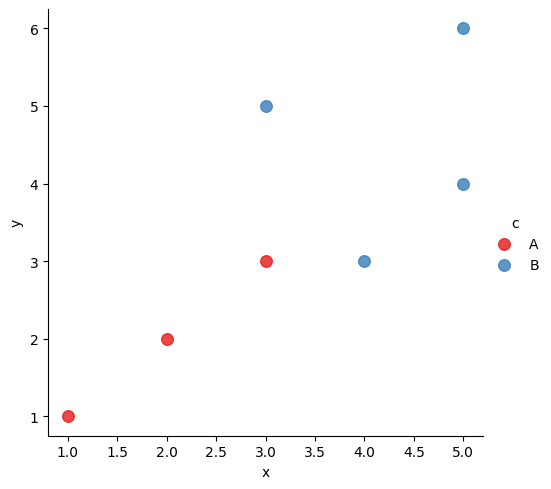

In [2]:
data = pd.read_csv("knn.csv")
sns.lmplot(x='x', y='y', data=data,
           hue='c', palette='Set1',
           fit_reg=False, scatter_kws={"s": 70})
plt.show()

<div dir="rtl">
نقاط متعلق به کلاس A به رنگ قرمز و نقاط متعلق به کلاس B به رنگ آبی نمایش داده می‌شوند.
</div>

<div dir="rtl">

## محاسبه فاصله بین نقاط

برای یافتن نزدیک‌ترین همسایه یک نقطه مشخص، باید فاصله اقلیدسی بین دو نقطه را محاسبه کنید.

**نکته:** در هندسه، فضای اقلیدسی شامل صفحه دوبعدی اقلیدسی، فضای سه‌بعدی هندسه اقلیدسی و فضاهای مشابه با ابعاد بالاتر است.

با توجه به دو نقطه \(p = (p_1, p_2, ..., p_n)\) و \(q = (q_1, q_2, ..., q_n)\)، فاصله بین p و q با فرمول زیر محاسبه می‌شود:
</div>
<div dir="ltr">

$$\sqrt{(q_1-p_1)^2 + (q_2-p_2)^2 + ... + (q_n-p_n)^2}$$

</div>
<div dir="rtl">
بر اساس این فرمول، اکنون می‌توانید تابعی به نام euclidean_distance() را به صورت زیر تعریف کنید:
</div>

In [3]:
#---to calculate the distance between two points---
def euclidean_distance(pt1, pt2, dimension):
    distance = 0
    for x in range(dimension):
        distance += np.square(pt1[x] - pt2[x])
    return np.sqrt(distance)


In [10]:
euclidean_distance([3,4],[0,0],2)

np.float64(5.0)

<div dir="rtl">
تابع euclidean_distance() می‌تواند فاصله بین دو نقطه را در هر بعدی پیدا کند. برای این مثال، نقاطی که با آنها کار می‌کنیم در دو بعد هستند.
</div>

<div dir="rtl">

## پیاده‌سازی KNN

سپس، تابعی به نام knn() تعریف کنید که نقاط آموزش، نقطه تست و مقدار k را دریافت می‌کند:
</div>

In [29]:
def knn(training_points, test_point, k):
    distances = {}
    
    # Number of coordinate columns (x, y)
    dimension = 2
    
    # Extract test point coordinates (first 2 columns)
    if isinstance(test_point, pd.DataFrame):
        test_coords = test_point.iloc[0, :2].values
    else:
        test_coords = test_point[:2]
    
    # Calculate Euclidean distance to each training point
    for x in range(len(training_points)):
        train_coords = training_points.iloc[x, :2].values
        dist = euclidean_distance(test_coords, train_coords, dimension)
        distances[x] = dist
    
    # Sort by distance
    sorted_d = sorted(distances.items(), key=operator.itemgetter(1))
    
    # Get top k neighbors
    neighbors = []
    for x in range(k):
        neighbors.append(sorted_d[x][0])
    
    # Count classes of neighbors (class is in column 3, index 2)
    class_counter = {}
    for x in range(len(neighbors)):
        cls = training_points.iloc[neighbors[x], 2]
        if cls in class_counter:
            class_counter[cls] += 1
        else:
            class_counter[cls] = 1
    
    # Sort classes by frequency (descending)
    sorted_counter = sorted(class_counter.items(), key=operator.itemgetter(1), reverse=True)
    
    # Return most common class and neighbor indices
    return(sorted_counter[0][0], neighbors)

<div dir="rtl">
تابع کلاسی را که نقطه تست به آن تعلق دارد و همچنین شاخص‌های تمام k همسایه نزدیک را برمی‌گرداند.
</div>

<div dir="rtl">

## انجام پیش‌بینی

با تعریف تابع knn()، اکنون می‌توانید برخی پیش‌بینی‌ها را انجام دهید:
</div>

In [36]:
#---test point---
test_set = [[3,3.9]]
test = pd.DataFrame(test_set)
cls,neighbors = knn(data, test, 5)
print("Predicted Class: " + cls)


Predicted Class: B


<div dir="rtl">

## تجسم مقادیر مختلف K

تجسم اثر اعمال مقادیر مختلف k مفید است. قطعه کد زیر یک سری دایره‌های متحدالمرکز را حول نقطه تست بر اساس مقادیر k که از 7 تا 1 با فواصل 2- متغیر است، رسم می‌کند:
</div>

k =  7
Class B
Neighbors
   x  y  c
3  3  3  A
4  3  5  B
2  4  3  B
6  5  4  B
1  2  2  A
5  5  6  B
0  1  1  A
k =  5
Class B
Neighbors
   x  y  c
3  3  3  A
4  3  5  B
2  4  3  B
6  5  4  B
1  2  2  A
k =  3
Class B
Neighbors
   x  y  c
3  3  3  A
4  3  5  B
2  4  3  B
k =  1
Class A
Neighbors
   x  y  c
3  3  3  A


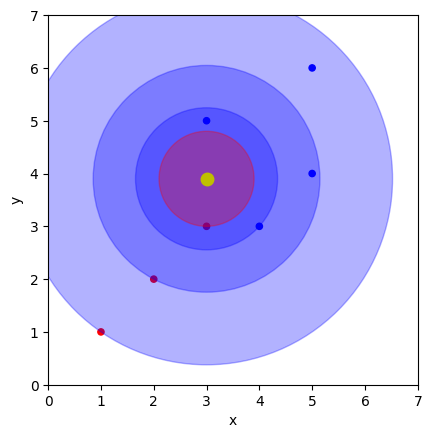

In [38]:
#---generate the color map for the scatter plot---
#---if column 'c' is A, then use Red, else use Blue---
colors = ['r' if i == 'A' else 'b'  for i in data['c']]
ax = data.plot(kind='scatter', x='x', y='y', c = colors)
plt.xlim(0,7)
plt.ylim(0,7)

#---plot the test point---
plt.plot(test_set[0][0],test_set[0][1], "yo", markersize='9')

# Extract test point coordinates properly
test_point_coords = [test_set[0][0], test_set[0][1]]  # [3, 3.9]

for k in range(7,0,-2):
    cls,neighbors = knn(data, test, k)
    print("============")
    print("k = ", k)
    print("Class", cls)
    print("Neighbors")
    print(data.iloc[neighbors])

    furthest_point = data.iloc[neighbors].tail(1)

    # Extract x,y coordinates from furthest point (ignore column c)
    furthest_coords = [furthest_point.iloc[0]['x'], furthest_point.iloc[0]['y']]

    #---draw a circle connecting the test point and the furthest point---
    radius = euclidean_distance(test_point_coords, furthest_coords, 2)

    #---display the circle in red if classification is A,
    # else display circle in blue---
    c = 'r' if cls=='A' else 'b'
    circle = plt.Circle((test_set[0][0], test_set[0][1]),
                        radius, color=c, alpha=0.3)
    ax.add_patch(circle)

plt.gca().set_aspect('equal', adjustable='box')
plt.show()


<div dir="rtl">
شکل 9.3 سری دایره‌های متحدالمرکز را حول نقطه تست با مقادیر مختلف k نشان می‌دهد. درونی‌ترین دایره برای k=1 است، با حلقه بیرونی بعدی برای k=3، و به همین ترتیب. همانطور که می‌بینید، اگر k=1 باشد، دایره قرمز است، به این معنی که نقطه زرد به عنوان کلاس A طبقه‌بندی شده است. اگر دایره آبی باشد، به این معنی است که نقطه زرد به عنوان کلاس B طبقه‌بندی شده است. این در سه دایره بیرونی مشهود است.
</div>

<div dir="rtl">

## استفاده از کلاس KNeighborsClassifier کتابخانه Scikit-Learn برای KNN

اکنون که دیدید KNN چگونه کار می‌کند و چگونه می‌توان آن را به صورت دستی در پایتون پیاده‌سازی کرد، بیایید از پیاده‌سازی ارائه شده توسط Scikit-learn استفاده کنیم.

قطعه کد زیر مجموعه داده Iris را بارگذاری می‌کند و آن را با استفاده از نمودار پراکندگی رسم می‌کند:
</div>

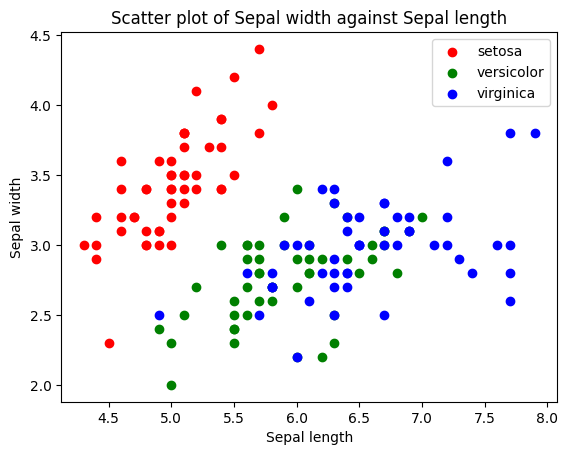

In [39]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.patches as mpatches
from sklearn import svm, datasets
import matplotlib.pyplot as plt

iris = datasets.load_iris()

X = iris.data[:, :2]       #  take the first two features
y = iris.target

#---plot the points---
colors = ['red', 'green', 'blue']
for color, i, target in zip(colors, [0, 1, 2], iris.target_names):
    plt.scatter(X[y==i, 0], X[y==i, 1], color=color, label=target)

plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.legend(loc='best', shadow=False, scatterpoints=1)

plt.title('Scatter plot of Sepal width against Sepal length')
plt.show()


<div dir="rtl">

## بررسی مقادیر مختلف K

اکنون می‌توانیم از کلاس KNeighborsClassifier کتابخانه Scikit-learn برای کمک به آموزش یک مدل بر روی مجموعه داده Iris با استفاده از KNN استفاده کنیم. برای شروع، بیایید از k=1 استفاده کنیم:
</div>

(array([0, 1, 2]), array([50, 60, 40]))


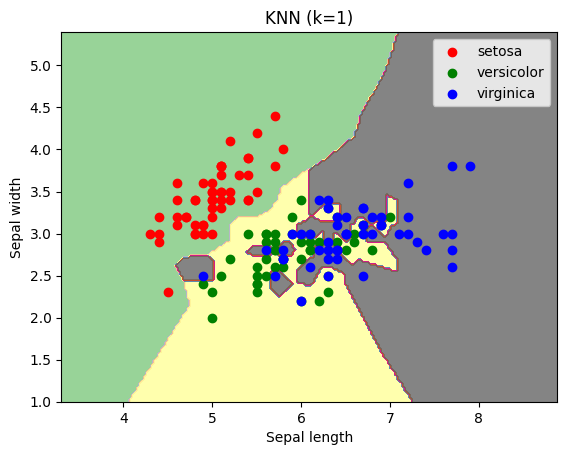

In [41]:
from sklearn.neighbors import KNeighborsClassifier

k = 1
#---instantiate learning model---
knn = KNeighborsClassifier(n_neighbors=k)

#---fitting the model---
knn.fit(X, y)

#---min and max for the first feature---
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1

#---min and max for the second feature---
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

#---step size in the mesh---
h = (x_max / x_min)/100

#---make predictions for each of the points in xx,yy---
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])

#---draw the result using a color plot---
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=plt.cm.Accent, alpha=0.8)

#---plot the training points---
colors = ['red', 'green', 'blue']
for color, i, target in zip(colors, [0, 1, 2], iris.target_names):
    plt.scatter(X[y==i, 0], X[y==i, 1], color=color, label=target)

plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.title(f'KNN (k={k})')
plt.legend(loc='best', shadow=False, scatterpoints=1)

predictions = knn.predict(X)

#--classifications based on predictions---
print(np.unique(predictions, return_counts=True))


<div dir="rtl">
قطعه کد بالا یک meshgrid (شبکه مستطیلی از مقادیر) از نقاط پراکنده در سراسر محورهای x و y ایجاد می‌کند. سپس از هر نقطه برای پیش‌بینی استفاده می‌شود و نتیجه با استفاده از یک نمودار رنگی رسم می‌شود.

شکل 9.5 مرز طبقه‌بندی را با استفاده از k=1 نشان می‌دهد. توجه داشته باشید که برای k=1، شما پیش‌بینی خود را صرفاً بر اساس یک نمونه‌—نزدیک‌ترین همسایه خود—انجام می‌دهید. این امر پیش‌بینی شما را به انواع مختلف اعوجاج‌ها، مانند نقاط پرت، برچسب‌گذاری اشتباه و غیره بسیار حساس می‌کند. به طور کلی، تنظیم k=1 معمولاً منجر به بیش‌برازش (overfitting) می‌شود و در نتیجه پیش‌بینی شما معمولاً بسیار دقیق نیست.
</div>

<div dir="rtl">

**نکته:** بیش‌برازش (Overfitting) در یادگیری ماشین به این معنی است که مدلی که آموزش داده‌اید بیش از حد به داده‌های آموزش می‌خورد. این اتفاق زمانی می‌افتد که تمام نویزها و نوسانات در داده‌های آموزشی شما در طول فرآیند آموزش جمع‌آوری می‌شوند. به زبان ساده، این به این معنی است که مدل شما بسیار تلاش می‌کند تا تمام داده‌های شما را به طور کامل fitting کند. مشکل کلیدی با یک مدل بیش‌برازش شده این است که با داده‌های جدید و دیده‌نشده به خوبی کار نخواهد کرد.

کم‌برازش (Underfitting)، از سوی دیگر، زمانی رخ می‌دهد که یک مدل یادگیری ماشین نمی‌تواند به طور دقیق روند زیربنایی داده را تشخیص دهد. به طور خاص، مدل به اندازه کافی داده را fitting نمی‌کند.

شکل 9.6 یک راه آسان برای درک بیش‌برازش، کم‌برازش و یک fit خوب را نشان می‌دهد.
</div>

<div dir="rtl">

**شکل 9.6:** درک مفهوم بیش‌برازش، کم‌برازش و یک fit خوب

<div style="display: flex; gap: 10px; justify-content: center; align-items: center;">
  <img src="9-6.png" width="700" height="300">

</div>


<div dir="rtl">
برای KNN، تنظیم k به مقدار بالاتر، پیش‌بینی شما را در برابر نویز در داده‌هایتان مقاوم‌تر می‌کند.

با استفاده از همان قطعه کد، بیایید مقادیر k را تغییر دهیم. شکل 9.7 طبقه‌بندی‌ها را بر اساس چهار مقدار مختلف k نشان می‌دهد.

توجه داشته باشید که با افزایش k، مرز صاف‌تر می‌شود. اما این همچنین به این معنی است که نقاط بیشتری به اشتباه طبقه‌بندی می‌شوند. وقتی k به مقدار زیادی افزایش می‌یابد، کم‌برازش رخ می‌دهد.

مسئله کلیدی با KNN این است که چگونه مقدار ایده‌آل k را برای استفاده پیدا می‌کنید؟
</div>

<div dir="rtl">

**شکل 9.7:** اثرات تغییر مقادیر k

<div style="display: flex; gap: 10px; justify-content: center; align-items: center;">
  <img src="9-7.png" width="700" height="450">
</div>



<div dir="rtl">

## اعتبارسنجی متقابل (Cross-Validation)

در چند فصل گذشته، شاهد بودید که مجموعه داده خود را به دو مجموعه جداگانه تقسیم کردیم - یکی برای آموزش و یکی برای تست. با این حال، داده‌های موجود در مجموعه داده شما ممکن است به طور مساوی توزیع نشوند، و در نتیجه مجموعه تست شما ممکن است برای پیش‌بینی بیش از حد ساده یا خیلی سخت باشد، بنابراین تشخیص اینکه آیا مدل شما به خوبی کار می‌کند را بسیار دشوار می‌کند.

به جای استفاده از بخشی از داده برای آموزش و بخشی برای تست، می‌توانید داده را به k بخش (folds) تقسیم کنید و مدل‌ها را k بار آموزش دهید، و مجموعه‌های آموزش و تست را جابجا کنید. با انجام این کار، هر نقطه داده اکنون برای آموزش و تست استفاده می‌شود.

**نکته:** k در k-fold را با k در KNN اشتباه نگیرید - آنها مرتبط نیستند.

شکل 9.8 یک مجموعه داده را نشان می‌دهد که به پنج بخش تقسیم شده است. برای اولین اجرا، بخش‌های 1، 2، 3 و 4 برای آموزش مدل استفاده می‌شوند. بخش 0 برای تست مدل استفاده می‌شود. در اجرای بعدی، بخش‌های 0، 2، 3 و 4 برای آموزش استفاده می‌شوند و بخش 1 برای تست استفاده می‌شود، و به همین ترتیب.
</div>

<div dir="rtl">
**شکل 9.8:** نحوه کار اعتبارسنجی متقابل
</div>

image_placeholder.png

<div dir="rtl">
در پایان هر اجرا، مدل امتیازدهی می‌شود. در پایان k اجرا، امتیاز میانگین گرفته می‌شود. این امتیاز میانگین به شما نشانه خوبی از عملکرد الگوریتم شما می‌دهد.

**نکته:** هدف از اعتبارسنجی متقابل آموزش مدل نیست، بلکه بررسی مدل است. اعتبارسنجی متقابل زمانی مفید است که نیاز به مقایسه الگوریتم‌های مختلف یادگیری ماشین دارید تا ببینید چگونه با مجموعه داده داده شده عمل می‌کنند. پس از انتخاب الگوریتم، از تمام داده‌ها برای آموزش مدل استفاده خواهید کرد.
</div>

<div dir="rtl">

## تنظیم پارامتر K

حالا که اعتبارسنجی متقابل را درک کردید، بیایید از آن بر روی مجموعه داده Iris خود استفاده کنیم. ما مدل را با استفاده از هر چهار ویژگی آموزش خواهیم داد، و در عین حال از اعتبارسنجی متقابل بر روی مجموعه داده با استفاده از 10 بخش استفاده خواهیم کرد. ما این کار را برای هر مقدار k انجام خواهیم داد:
</div>

In [9]:
from sklearn.model_selection import cross_val_score

#---holds the cv (cross-validates) scores---
cv_scores = []

#---use all features---
X = iris.data[:, :4]
y = iris.target

#---number of folds---
folds = 10

#---creating odd list of K for KNN---
ks = list(range(1,int(len(X) * ((folds - 1)/folds))))

#---remove all multiples of 3---
ks = [k for k in ks if k % 3 != 0]

#---perform k-fold cross validation---
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)

    #---performs cross-validation and returns the average accuracy---
    scores = cross_val_score(knn, X, y, cv=folds, scoring='accuracy')
    mean = scores.mean()
    cv_scores.append(mean)
    print(k, mean)


1 0.96
2 0.9533333333333334
4 0.9666666666666666
5 0.9666666666666668
7 0.9666666666666668
8 0.9666666666666668
10 0.9666666666666668
11 0.9666666666666668
13 0.9800000000000001
14 0.9733333333333334
16 0.9733333333333334
17 0.9733333333333334
19 0.9733333333333334
20 0.9800000000000001
22 0.9666666666666666
23 0.9733333333333334
25 0.9666666666666666
26 0.96
28 0.9533333333333334
29 0.9533333333333334
31 0.9466666666666667
32 0.9466666666666667
34 0.9466666666666667
35 0.9466666666666667
37 0.9466666666666667
38 0.9466666666666667
40 0.9533333333333334
41 0.9533333333333334
43 0.9466666666666667
44 0.9400000000000001
46 0.9333333333333333
47 0.9333333333333333
49 0.9400000000000001
50 0.9266666666666667
52 0.9333333333333333
53 0.9333333333333333
55 0.9333333333333333
56 0.9066666666666666
58 0.9133333333333334
59 0.9200000000000002
61 0.9199999999999999
62 0.9066666666666666
64 0.9
65 0.9
67 0.8866666666666667
68 0.8800000000000001
70 0.8866666666666667
71 0.8866666666666667
73 0.893

<div dir="rtl">
کتابخانه Scikit-learn تابع cross_val_score() را فراهم می‌کند که اعتبارسنجی متقابل را به طور خودکار برای شما انجام می‌دهد و معیارهایی را که می‌خواهید (مثلاً دقت) برمی‌گرداند.

هنگام استفاده از اعتبارسنجی متقابل، توجه داشته باشید که در هر زمان، ((folds-1)/folds) * total_rows برای آموزش در دسترس خواهد بود.这是因为 (1/folds) * total_rows برای تست استفاده خواهد شد.

برای KNN، سه قانون وجود دارد که باید رعایت کنید:
1. مقدار k نمی‌تواند از تعداد سطرها برای آموزش بیشتر باشد.
2. مقدار k باید یک عدد فرد باشد (تا بتوانید از موقعیت‌هایی که تساوی بین کلاس‌ها وجود دارد جلوگیری کنید) برای یک مسئله دو کلاسه.
3. مقدار k نباید مضربی از تعداد کلاس‌ها باشد (برای جلوگیری از تساوی، مشابه نکته قبلی).

از این رو، لیست ks در قطعه کد بالا شامل مقادیر زیر خواهد بود:

[1, 2, 4, 5, 7, 8, 10, 11, 13, 14, 16, 17, 19, 20, 22, 23, 25, 26, 28, 29, 31, 32, 34, 35, 37, 38, 40, 41, 43, 44, 46, 47, 49, 50, 52, 53, 55, 56, 58, 59, 61, 62, 64, 65, 67, 68, 70, 71, 73, 74, 76, 77, 79, 80, 82, 83, 85, 86, 88, 89, 91, 92, 94, 95, 97, 98, 100, 101, 103, 104, 106, 107, 109, 110, 112, 113, 115, 116, 118, 119, 121, 122, 124, 125, 127, 128, 130, 131, 133, 134]

پس از آموزش، cv_scores شامل لیستی از دقت‌ها بر اساس مقادیر مختلف k خواهد بود:

```
1 0.96
2 0.9533333333333334
4 0.9666666666666666
...
128 0.6199999999999999
130 0.6066666666666667
131 0.5933333333333332
133 0.5666666666666667
134 0.5533333333333333
```
</div>

<div dir="rtl">

## یافتن k بهینه

برای یافتن k بهینه، به سادگی مقدار k را پیدا می‌کنید که بیشترین دقت را می‌دهد. یا در این مورد، می‌خواهید کمترین خطای طبقه‌بندی اشتباه (MSE) را پیدا کنید. قطعه کد زیر MSE را برای هر k پیدا می‌کند و سپس k را با کمترین MSE پیدا می‌کند. سپس یک نمودار خطی از MSE در مقابل k رسم می‌کند (شکل 9.9 را ببینید):
</div>

In [10]:
#---calculate misclassification error for each k---
MSE = [1 - x for x in cv_scores]

#---determining best k (min. MSE)---
optimal_k = ks[MSE.index(min(MSE))]
print(f"The optimal number of neighbors is {optimal_k}")

#---plot misclassification error vs k---
plt.plot(ks, MSE)
plt.xlabel('Number of Neighbors K')
plt.ylabel('Misclassification Error')
plt.show()


The optimal number of neighbors is 13


<div dir="rtl">
قطعه کد بالا خروجی زیر را چاپ می‌کند:

```
The optimal number of neighbors is 13
```
</div>

<div dir="rtl">
**شکل 9.9:** نمودار خطاهای طبقه‌بندی اشتباه برای هر k
</div>

image_placeholder.png

<div dir="rtl">
**شکل 9.10:** مقدار بهینه k در 13
</div>

image_placeholder.png

<div dir="rtl">

## خلاصه

از میان چهار الگوریتمی که در این کتاب بحث کردیم، KNN یکی از ساده‌ترین‌ها محسوب می‌شود. در این فصل، شما یاد گرفتید که KNN چگونه کار می‌کند و چگونه می‌توان k بهینه را که خطای محاسباتی خطاها را به حداقل می‌رساند، استخراج کرد.

در فصل بعد، شما با نوع جدیدی از الگوریتم—یادگیری بدون نظارت—آشنا خواهید شد. شما یاد خواهید گرفت که چگونه ساختارهای داده‌های خود را با انجام خوشه‌بندی با استفاده از K-Means کشف کنید.
</div>